In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import shap

In [3]:
transactions = pd.read_csv(
    "data/processed/clean_transactions.csv"
)

transactions["invoicedate"] = pd.to_datetime(
    transactions["invoicedate"]
)

transactions.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,is_return,revenue,year,month,month_name,day,day_name,hour,quarter,week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,False,83.4,2009,12,December,1,Tuesday,7,4,49
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,81.0,2009,12,December,1,Tuesday,7,4,49
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,81.0,2009,12,December,1,Tuesday,7,4,49
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,False,100.8,2009,12,December,1,Tuesday,7,4,49
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,False,30.0,2009,12,December,1,Tuesday,7,4,49


In [4]:
print("Shape :", transactions.shape)

print("\nCustomers :", transactions["customer_id"].nunique())

print("Invoices :", transactions["invoice"].nunique())

print("\nStart :", transactions["invoicedate"].min())

print("End :", transactions["invoicedate"].max())

Shape : (797885, 19)

Customers : 5942
Invoices : 44876

Start : 2009-12-01 07:45:00
End : 2011-12-09 12:50:00


In [5]:
snapshot_date = transactions["invoicedate"].max()

cutoff_date = snapshot_date - pd.DateOffset(months=3)

print("Cutoff :", cutoff_date)

print("Snapshot :", snapshot_date)

Cutoff : 2011-09-09 12:50:00
Snapshot : 2011-12-09 12:50:00


In [6]:
historical = transactions[
    transactions["invoicedate"] <= cutoff_date
].copy()

future = transactions[
    transactions["invoicedate"] > cutoff_date
].copy()

print("Historical :", historical.shape)

print("Future :", future.shape)

Historical : (635177, 19)
Future : (162708, 19)


In [7]:
print("Historical Customers :",
      historical["customer_id"].nunique())

print("Future Customers :",
      future["customer_id"].nunique())

Historical Customers : 5344
Future Customers : 2922


In [8]:
customer_status = pd.DataFrame({
    "customer_id":
    historical["customer_id"].unique()
})

customer_status["returned"] = (
    customer_status["customer_id"]
    .isin(future["customer_id"].unique())
)

customer_status["churn"] = (
    ~customer_status["returned"]
).astype(int)

customer_status["churn"].value_counts()

churn
1    3020
0    2324
Name: count, dtype: int64

In [9]:
customer_status["churn"] \
.value_counts(normalize=True) * 100

churn
1    56.511976
0    43.488024
Name: proportion, dtype: float64

In [10]:
historical_sales = historical[
    (~historical["is_return"]) &
    (~historical["is_cancelled"])
].copy()

print(historical_sales.shape)

historical_sales.head()
snapshot = historical_sales["invoicedate"].max()

print(snapshot)

(619952, 19)
2011-09-09 12:41:00


In [11]:
customer_df = pd.DataFrame({
    "customer_id":
    historical_sales["customer_id"].unique()
})

customer_df.head()

,customer_id
0,13085
1,13078
2,15362
3,18102
4,12682


In [12]:
rfm = (
    historical_sales
    .groupby("customer_id")
    .agg(
        recency=(
            "invoicedate",
            lambda x: (snapshot - x.max()).days
        ),
        frequency=("invoice","nunique"),
        monetary=("revenue","sum")
    )
    .reset_index()
)

customer_df = customer_df.merge(
    rfm,
    on="customer_id",
    how="left"
)

spending = (
    historical_sales
    .groupby("customer_id")
    .agg(
        avg_order_value=("revenue","mean"),
        total_orders=("invoice","nunique"),
        total_revenue=("revenue","sum"),
        total_products=("quantity","sum")
    )
    .reset_index()
)

spending["avg_revenue_per_product"] = np.where(
    spending["total_products"] > 0,
    spending["total_revenue"] /
    spending["total_products"],
    0
)

customer_df = customer_df.merge(
    spending[
        [
            "customer_id",
            "avg_order_value",
            "avg_revenue_per_product",
            "total_products"
        ]
    ],
    on="customer_id",
    how="left"
)


product = (
    historical_sales
    .groupby("customer_id")
    .agg(
        unique_products=("stockcode", "nunique")
    )
    .reset_index()
)

customer_df = customer_df.merge(
    product,
    on="customer_id",
    how="left"
)

customer_df["avg_basket_size"] = np.where(
    customer_df["frequency"] > 0,
    customer_df["total_products"] /
    customer_df["frequency"],
    0
)

customer_df["product_diversity"] = np.where(
    customer_df["total_products"] > 0,
    customer_df["unique_products"] /
    customer_df["total_products"],
    0
)



lifetime = (
    historical_sales
    .groupby("customer_id")
    .agg(
        first_purchase=("invoicedate", "min"),
        last_purchase=("invoicedate", "max")
    )
    .reset_index()
)

lifetime["customer_lifetime_days"] = (
    lifetime["last_purchase"] -
    lifetime["first_purchase"]
).dt.days

lifetime["days_since_first_purchase"] = (
    snapshot -
    lifetime["first_purchase"]
).dt.days

customer_df = customer_df.merge(
    lifetime[
        [
            "customer_id",
            "customer_lifetime_days",
            "days_since_first_purchase"
        ]
    ],
    on="customer_id",
    how="left"
)




sales_sorted = (
    historical_sales
    .sort_values(
        ["customer_id", "invoicedate"]
    )
)

sales_sorted["purchase_gap"] = (
    sales_sorted
    .groupby("customer_id")["invoicedate"]
    .diff()
    .dt.days
)

purchase_stats = (
    sales_sorted
    .groupby("customer_id")
    .agg(
        avg_purchase_interval=("purchase_gap", "mean"),
        purchase_consistency=("purchase_gap", "std")
    )
    .reset_index()
)

customer_df = customer_df.merge(
    purchase_stats,
    on="customer_id",
    how="left"
)

customer_df["avg_purchase_interval"] = (
    customer_df["avg_purchase_interval"].fillna(0)
)

customer_df["purchase_consistency"] = (
    customer_df["purchase_consistency"].fillna(0)
)


customer_df["purchase_frequency_per_month"] = np.where(
    customer_df["customer_lifetime_days"] > 0,
    customer_df["frequency"] /
    (customer_df["customer_lifetime_days"] / 30),
    customer_df["frequency"]
)

active_months = (
    historical_sales
    .assign(
        year_month=historical_sales["invoicedate"].dt.to_period("M")
    )
    .groupby("customer_id")["year_month"]
    .nunique()
    .reset_index(name="active_months")
)

customer_df = customer_df.merge(
    active_months,
    on="customer_id",
    how="left"
)



return_features = (
    historical
    .groupby("customer_id")
    .agg(
        total_transactions=("invoice", "count"),
        total_returns=("is_return", "sum"),
        total_cancelled=("is_cancelled", "sum")
    )
    .reset_index()
)

return_features["return_rate"] = (
    return_features["total_returns"] /
    return_features["total_transactions"]
)

return_features["cancellation_rate"] = (
    return_features["total_cancelled"] /
    return_features["total_transactions"]
)

customer_df = customer_df.merge(
    return_features[
        [
            "customer_id",
            "return_rate",
            "cancellation_rate"
        ]
    ],
    on="customer_id",
    how="left"
)


In [13]:
customer_df = customer_df.merge(
    customer_status[
        [
            "customer_id",
            "churn"
        ]
    ],
    on="customer_id",
    how="inner"
)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,avg_revenue_per_product,total_products,unique_products,avg_basket_size,product_diversity,customer_lifetime_days,days_since_first_purchase,avg_purchase_interval,purchase_consistency,purchase_frequency_per_month,active_months,return_rate,cancellation_rate,churn
0,13085,66,8,2433.28,28.967619,2.577627,944,50,118.000000,0.052966,581,647,6.975904,44.901783,0.413081,4,0.086957,0.086957,1
1,13078,15,46,23307.27,33.926157,2.618206,8902,141,193.521739,0.015839,632,647,0.893586,3.784184,2.183544,21,0.064033,0.064033,0
2,15362,357,2,613.08,15.327000,1.665978,368,38,184.000000,0.103261,290,647,7.435897,46.437165,0.206897,2,0.000000,0.000000,1
3,18102,7,112,456780.49,591.684573,3.065764,148994,311,1330.303571,0.002087,640,647,0.788586,4.153318,5.250000,20,0.012788,0.012788,0
4,12682,9,41,18890.32,23.036976,2.222914,8498,281,207.268293,0.033067,638,647,0.753358,4.157677,1.927900,21,0.003645,0.003645,0


In [14]:
customer_df.fillna(0, inplace=True)

print("Shape :", customer_df.shape)

print("\nMissing Values\n")
print(customer_df.isnull().sum())

Shape : (5281, 19)

Missing Values

customer_id                     0
recency                         0
frequency                       0
monetary                        0
avg_order_value                 0
avg_revenue_per_product         0
total_products                  0
unique_products                 0
avg_basket_size                 0
product_diversity               0
customer_lifetime_days          0
days_since_first_purchase       0
avg_purchase_interval           0
purchase_consistency            0
purchase_frequency_per_month    0
active_months                   0
return_rate                     0
cancellation_rate               0
churn                           0
dtype: int64


In [15]:
customer_df.to_csv(
    "data/processed/churn_dataset.csv",
    index=False
)

print("Saved Successfully!")

Saved Successfully!


In [16]:
df = pd.read_csv(
    "data/processed/churn_dataset.csv"
)

df.head()

,customer_id,recency,frequency,monetary,avg_order_value,avg_revenue_per_product,total_products,unique_products,avg_basket_size,product_diversity,customer_lifetime_days,days_since_first_purchase,avg_purchase_interval,purchase_consistency,purchase_frequency_per_month,active_months,return_rate,cancellation_rate,churn
0,13085,66,8,2433.28,28.967619,2.577627,944,50,118.000000,0.052966,581,647,6.975904,44.901783,0.413081,4,0.086957,0.086957,1
1,13078,15,46,23307.27,33.926157,2.618206,8902,141,193.521739,0.015839,632,647,0.893586,3.784184,2.183544,21,0.064033,0.064033,0
2,15362,357,2,613.08,15.327000,1.665978,368,38,184.000000,0.103261,290,647,7.435897,46.437165,0.206897,2,0.000000,0.000000,1
3,18102,7,112,456780.49,591.684573,3.065764,148994,311,1330.303571,0.002087,640,647,0.788586,4.153318,5.250000,20,0.012788,0.012788,0
4,12682,9,41,18890.32,23.036976,2.222914,8498,281,207.268293,0.033067,638,647,0.753358,4.157677,1.927900,21,0.003645,0.003645,0


In [17]:
X = df.drop(
    columns=[
        "customer_id",
        "churn"
    ]
)

y = df["churn"]

print(X.shape)

print(y.shape)

(5281, 17)
(5281,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

(4224, 17)
(1057, 17)


logistic regression

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

RF

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

XGB

In [21]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

evaluation

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, pred, prob):

    print("="*60)

    print(name)

    print("="*60)

    print("Accuracy :", accuracy_score(y_true,pred))

    print("Precision:", precision_score(y_true,pred))

    print("Recall   :", recall_score(y_true,pred))

    print("F1 Score :", f1_score(y_true,pred))

    print("ROC AUC  :", roc_auc_score(y_true,prob))
    
    
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

Logistic Regression
Accuracy : 0.7313150425733207
Precision: 0.7429022082018928
Recall   : 0.7956081081081081
F1 Score : 0.768352365415987
ROC AUC  : 0.7914014821272886
Random Forest
Accuracy : 0.7199621570482497
Precision: 0.7291021671826625
Recall   : 0.7956081081081081
F1 Score : 0.7609046849757674
ROC AUC  : 0.7901700087183958
XGBoost
Accuracy : 0.7142857142857143
Precision: 0.7287066246056783
Recall   : 0.7804054054054054
F1 Score : 0.7536704730831973
ROC AUC  : 0.784016274338855


In [23]:
from sklearn.metrics import classification_report

print("Logistic Regression\n")

print(
    classification_report(
        y_test,
        lr_pred
    )
)

print("="*70)

print("Random Forest\n")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

print("="*70)

print("XGBoost\n")

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

Logistic Regression

              precision    recall  f1-score   support

           0       0.71      0.65      0.68       465
           1       0.74      0.80      0.77       592

    accuracy                           0.73      1057
   macro avg       0.73      0.72      0.72      1057
weighted avg       0.73      0.73      0.73      1057

Random Forest

              precision    recall  f1-score   support

           0       0.71      0.62      0.66       465
           1       0.73      0.80      0.76       592

    accuracy                           0.72      1057
   macro avg       0.72      0.71      0.71      1057
weighted avg       0.72      0.72      0.72      1057

XGBoost

              precision    recall  f1-score   support

           0       0.69      0.63      0.66       465
           1       0.73      0.78      0.75       592

    accuracy                           0.71      1057
   macro avg       0.71      0.71      0.71      1057
weighted avg       0.71      

<Figure size 500x500 with 0 Axes>

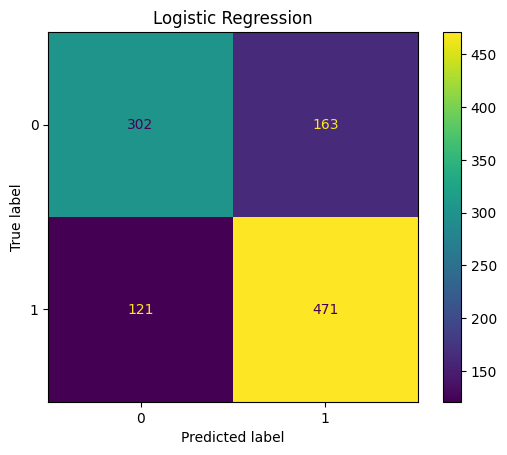

<Figure size 500x500 with 0 Axes>

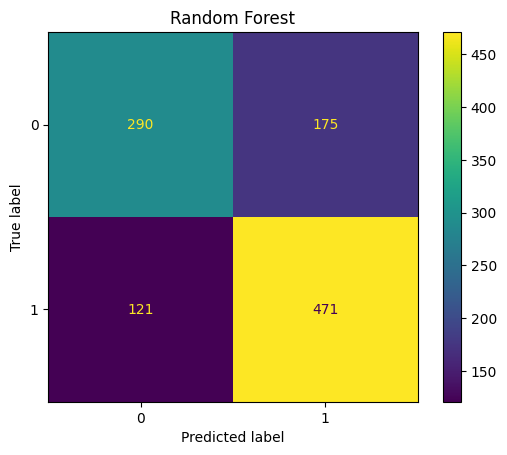

<Figure size 500x500 with 0 Axes>

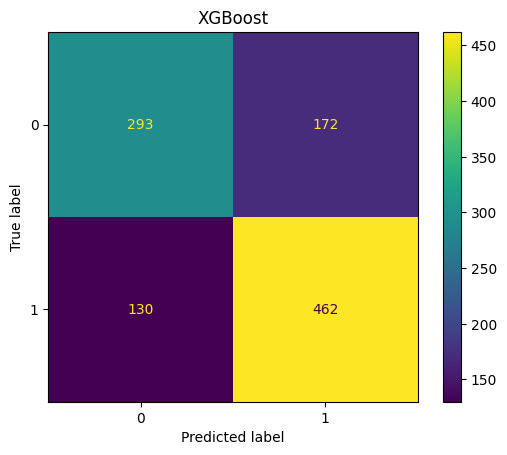

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

predictions = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name in models:

    plt.figure(figsize=(5,5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name]
    )

    plt.title(name)

    plt.show()

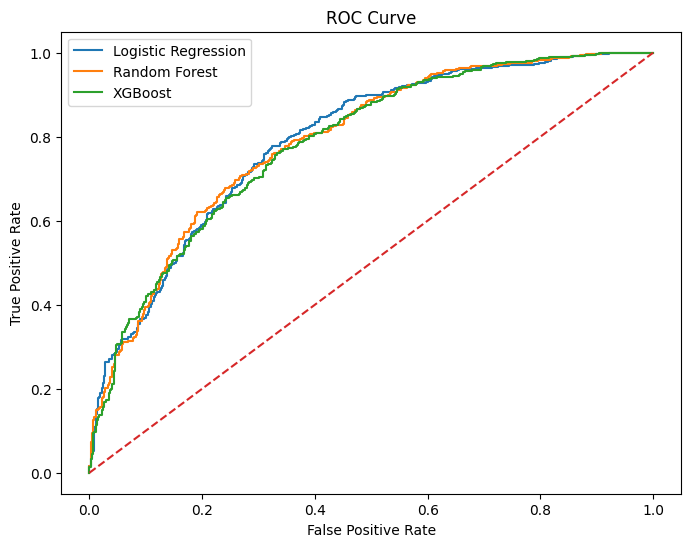

In [25]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name,prob in {

    "Logistic Regression":lr_prob,

    "Random Forest":rf_prob,

    "XGBoost":xgb_prob

}.items():

    fpr,tpr,_ = roc_curve(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=name
    )

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [26]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance.head(15)

,Feature,Importance
1,frequency,0.169618
0,recency,0.135098
14,active_months,0.111211
2,monetary,0.051678
12,purchase_consistency,0.050443
9,customer_lifetime_days,0.049914
6,unique_products,0.048662
10,days_since_first_purchase,0.046102
5,total_products,0.044866
13,purchase_frequency_per_month,0.042104


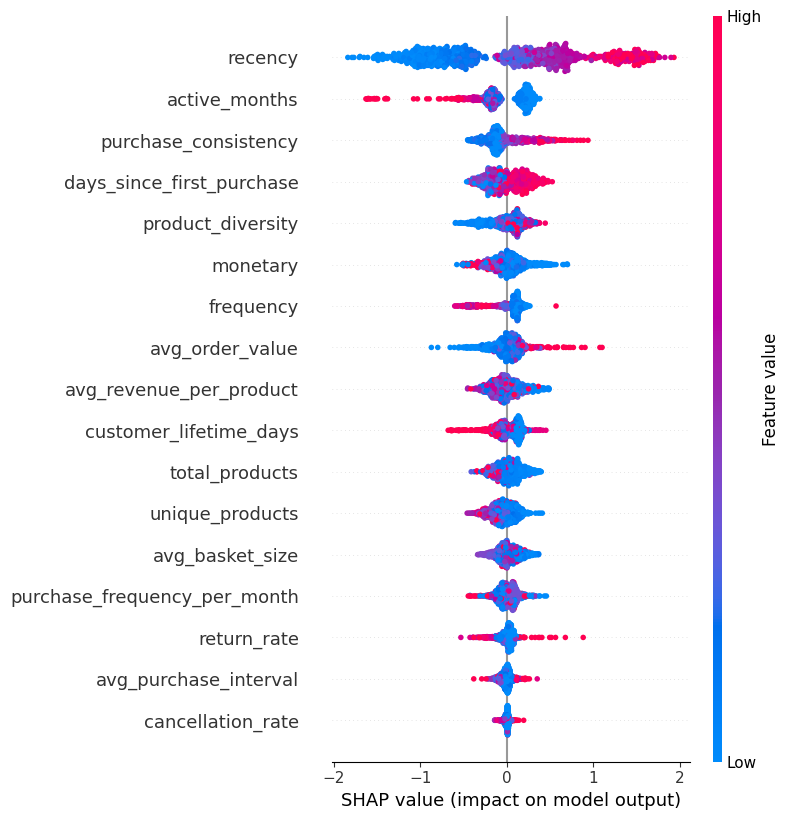

In [27]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(

    shap_values,

    X_test
)

In [28]:
results = X_test.copy()

results["customer_id"] = (
    df.loc[X_test.index, "customer_id"].values
)

results["Actual"] = y_test.values

results["Predicted"] = rf_pred

results["Probability"] = rf_prob

results = results[
    [
        "customer_id",
        "Actual",
        "Predicted",
        "Probability"
    ]
]

results.to_csv(
    "data/processed/churn_predictions.csv",
    index=False
)

results.head()

,customer_id,Actual,Predicted,Probability
265,14750,1,1,0.894244
1495,13288,1,1,0.726009
3,18102,0,0,0.029265
5245,12814,1,1,0.734328
4586,15206,0,0,0.394927


In [29]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

comparison = comparison.sort_values(
    "ROC_AUC",
    ascending=False
)

comparison


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.731315,0.742902,0.795608,0.768352,0.791401
1,Random Forest,0.719962,0.729102,0.795608,0.760905,0.790170
2,XGBoost,0.714286,0.728707,0.780405,0.753670,0.784016


In [30]:
import joblib

joblib.dump(
    xgb,
    "models/churn_model.pkl"
)

joblib.dump(
    scaler,
    "models/churn_scaler.pkl"
)

print("Models Saved!")

Models Saved!
